# E-Commerce Sales Analysis

## Project Overview

This project analyzes an e-commerce dataset from Brazilian marketplace **Olist**.

The objective of this analysis is to explore sales performance and generate insights that could help improve business decisions.

Through this analysis we will answer questions such as:
- How have sales envolved over time?
- Wich product categories generate the most reveue?
- Where are costumers located?
- Wich products sell the most?

This project demostrates core Data Analyst skills including:
- Data cleaning
- Exploratory Data Analysis (EDA)
- Data transformation
- Data visualization
- Business insight generation 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Data

The dataset consists of multiple tables representing diferent entities in the e-commerce platform.

The main table used in this analysis are:
- **orders** -> information about each order
- **order_items** -> products included in each order
- **products** -> product information
- **customers** -> customer information

This tables are connected through unique identifiers such as `order_id`, `product_id`, and `customer_id`.

In [2]:
orders = pd.read_csv("../data/raw/orders.csv")
order_items = pd.read_csv("../data/raw/order_items.csv")
products = pd.read_csv("../data/raw/products.csv")
customers = pd.read_csv("../data/raw/customers.csv")

## Previewing the Data

Before performing any analysis, it is important to inspect the datasets

This step helps us understand:
- The structure of the data
- Column names
- Potential missing values
- Data types

In [3]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


## Dataset dimensions

Understanding the size of each dataset helps estimate the scale of the analysis

In [4]:
orders.shape
order_items.shape

(112650, 7)

## Checking Missing Values

Before starting the analysis, it is important to verify whether the dataset contains missing values.

Missing data can affect calculations and visuallizations, so identifying them early helps ensure the reliability of the analysis.

In [5]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

## Cheking for Duplicate Records

Duplicate rows can distort the analysis by counting the same event multiple times.

Therefore, we check if duplicate records exist in the dataset.

In [6]:
orders.duplicated().sum()

np.int64(0)

## Exploring the Orders Dataset

The `orders` table contains information about each order placed in the platform.

Key columns include:
- `order_id` → unique identifier for each order
- `customer_id` → identifies the customer who placed the order
- `order_purchase_timestamp` → time when the purchase occurred
- `order_status` → status of the order

In [7]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

## Converting Date Columns

To perform time-based analysis, we convert the purchase timestamp into datetime format.

This allows us to extract information such as:
- year
- month
- day

In [8]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])

## Filtering Completed Orders

For the purpose of sales analysis, we will focus only on orders that were successfully delivered

Orders with other statuses such as canceled or unavailable do not represent completed sales and therefore do not generate revenue.

In [9]:
delivered_orders = orders[orders["order_status"] == "delivered"]

In [28]:
delivered_orders.shape

(96478, 8)

## Explore Order Items

The `order_items` table contains information about the products included in each order.


Key columns include:

- `order_id`
- `product_id`
- `price`
- `freight_value`

Each row represents a product within an order

In [29]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [12]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


## Merging Orders and Order Items

To analyse sales revenue, we need to combine the `orders` dataset with the `order_items` dataset.

The connection between this tables is the `order_id`.

This merge allows us to associate each product purchase with its coresponding order.

In [37]:
sales = pd.merge(
    delivered_orders,
    order_items,
    on="order_id",
    how="inner"
).merge(
    customers[["customer_state", "customer_id"]],
    on="customer_id",
    how="left"
)

In [38]:
sales.shape

(110197, 15)

## Understanding revenue

The `price` column represents the value of each product purchased.

Since each row represents a single product eithin an order, the total revenue can be calculated by summing the `price` column.

In [39]:
total_revenue = sales["price"].sum()
total_revenue

np.float64(13221498.110000001)

## Total Number of Orders

Another important metric is te total number of completed orders.

This metric helps understand the volume of transactions processed bu the platform.

In [40]:
total_orders = sales["order_id"].nunique()

## Average Order Value (AOV)

The Averacie Order Value represents the average amount spent per order.

This metric is widely used in e-commerce to understand customer purchasing behavior.


In [41]:
average_order_value = total_revenue / total_orders

In [42]:
total_revenue

np.float64(13221498.110000001)

In [43]:
total_orders

96478

In [44]:
average_order_value

np.float64(137.04158575011922)

In [45]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110197 entries, 0 to 110196
Data columns (total 15 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110197 non-null  object        
 1   customer_id                    110197 non-null  object        
 2   order_status                   110197 non-null  object        
 3   order_purchase_timestamp       110197 non-null  datetime64[ns]
 4   order_approved_at              110182 non-null  object        
 5   order_delivered_carrier_date   110195 non-null  object        
 6   order_delivered_customer_date  110189 non-null  object        
 7   order_estimated_delivery_date  110197 non-null  object        
 8   order_item_id                  110197 non-null  int64         
 9   product_id                     110197 non-null  object        
 10  seller_id                      110197 non-null  object        
 11  

## Extracting Purchase Month

To analyse sales trends over time, we extract the purchase month from the order timestamp.

In [46]:
sales["purchase_month"] = sales["order_purchase_timestamp"].dt.to_period("M")

## Monthly Revenue Analysis

To understand how the business evolves over time, we calculate the total revenue generated each month.

This allows us to identify trends, growth patterns, and potential seasonality in sales.

In [47]:
monthly_revenue = sales.groupby("purchase_month")["price"].sum()

## Sales Trend Visualization

Visualizing revenue over time helps identify growth patterns and fluctuations in sales performance.

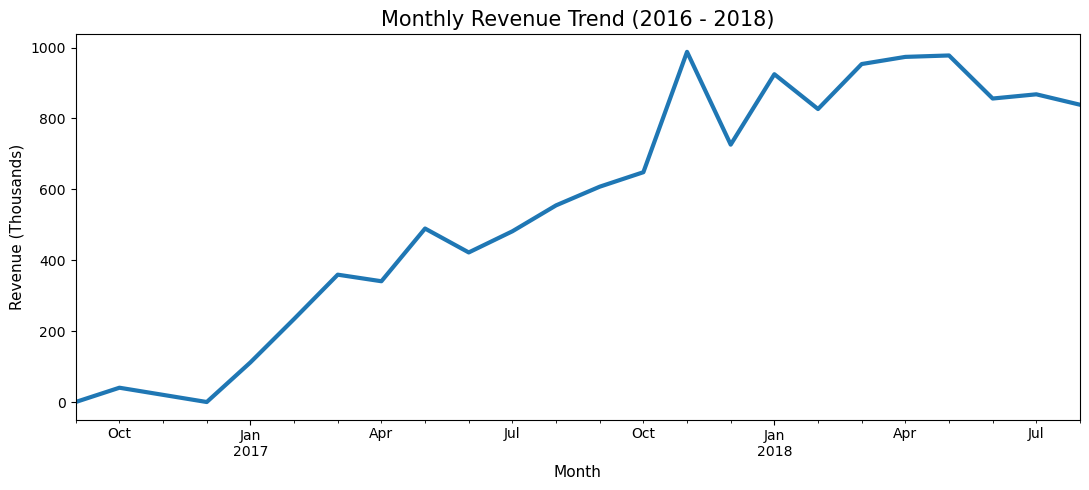

In [48]:
monthly_revenue_k = monthly_revenue / 1000

plt.figure(figsize=(11,5))

monthly_revenue_k.plot(linewidth=3)

plt.title("Monthly Revenue Trend (2016 - 2018)", fontsize=15)
plt.xlabel("Month", fontsize=11)
plt.ylabel("Revenue (Thousands)", fontsize=11)

plt.tight_layout()

plt.show()

In [49]:
products.info()
products.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


## Translating Product Categories

The product categories in the dataset are originally in Portuguese.

To make the analysis easier to interpret, we merge the product dataset with a translation table that provides the category names in english.


In [50]:
products = pd.read_csv("../data/raw/products.csv")

category_translation = pd.read_csv("../data/raw/product_category_name_translation.csv")

products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [53]:
products = products.merge(
    category_translation[["product_category_name_english", "product_category_name"]],
    on="product_category_name",
    how="left"
)
products.head()


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english_x,product_category_name_english_y
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares,housewares


## Adding Product Categories to the Sales Data

To analyze revenue by product category, we merge the sales dataset with the products dataset.

This allows us to associate each purchased item with its product category.

In [ ]:
sales = sales.merge(
    products[["product_id", "product_category_name_english"]],
    on="product_id",
    how="left"
)
sales.head()

## Revenue by Product Category

Understanding wich product categories generate the most revenue gelps identify the core drivers of the business.

This analysis aggregates total revenue by product category.

In [ ]:
category_revenue = (
    sales
    .groupby("product_category_name_english_x")["price"]
    .sum()
    .sort_values(ascending=False)
)

In [ ]:
category_revenue.head(10)

## Top Revenue Generating Categories

Visualizing the top product categories helps identify wich segments contribute the most to overall revenue.

In [ ]:
top_categories = category_revenue.head(10)

plt.figure(figsize=(10,6))

top_categories.plot(kind="bar")

plt.title("Top 10 Products Categories by Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

## Key Insight

The categories generating the highest revenue are Health & Beuauty, Watches & Gifts, Bath & Table.

These categories represent consumer goods with strong demand in e-commerce, including personal care products, gift items, and home essentials.

Their high revenue contribution suggests that everyday-use products and lifestyle accessories play a major role in the platform's overall sales performance.

## Most Sold Products

Identifying the most frequently purchased products helps business understand wich items are most popular among costumers.

This analysis counts how many times each product appears in completed orders.

In [ ]:
top_products = (
    sales
    .groupby("product_id")["order_id"]
    .count()
    .sort_values(ascending=False)
)

## Top Selling Products

The following chart shows the products with the highest numer of items sold on the platform.

In [ ]:
top_ten_products = top_products.head(10)

plt.figure(figsize=(19,6))

top_ten_products.plot(kind="bar")

plt.title("Top 10 Most Sold Products")
plt.xlabel("Product ID")
plt.ylabel("Number of Items Sold")

plt.tight_layout()

plt.show()

## Customers Distrbutio by State

Analyzing the geographic distribution of costumers helps identify the regions where the platform has the highest concentration of users.

In [56]:
customers_by_state = (
    sales
    .groupby("customer_state")["customer_id"]
    .nunique()
    .sort_values(ascending=False)
)

customers_by_state.head(10)

customer_state
SP    40501
RJ    12350
MG    11354
RS     5345
PR     4923
SC     3546
BA     3256
DF     2080
ES     1995
GO     1957
Name: customer_id, dtype: int64

## Top Customer Locations

The following chart shows the states with the highest number of unique customers.

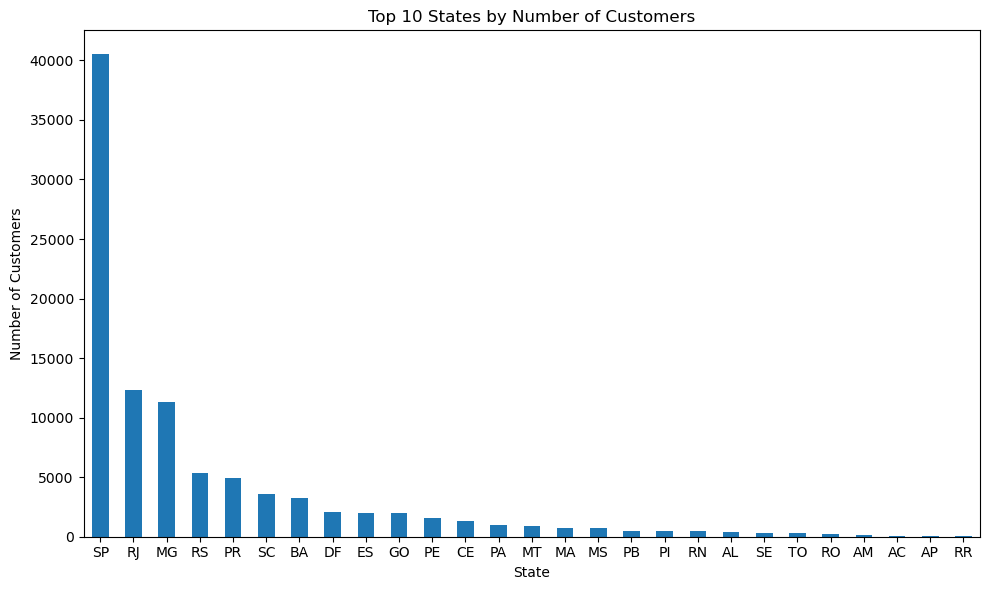

In [58]:
top_states = customers_by_state

plt.figure(figsize=(10,6))

top_states.plot(kind="bar")

plt.title("Top 10 States by Number of Customers")
plt.xlabel("State")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

## Geographic insight 

Customer distribution is concentrated in a small number of states.
The state of **Sao Paulo (SP)** represents the largest share of customers, followed by other economically strong regions. This suggests that demand on the platform is strongest in major urban and economic centers.
Understanding this geographic patterns can help business focus marketing strategies and optimize logistics operations.

## Project Conclusion

This project explored sales data from an e-commerce platform to understand key drivers of business performance.

Several important insights emerged from the analysis:

- **Revenue trends:** Monthly revenue analysis showed the evolution of sales activity over time.
- **Top product categories:** Health & Beauty, Watches & Gifts, and Bed & Bath products generated the highest revenue.
- **Popular products:** Certain products apeared significantly more frequently in orders, indicating strong customer demand.
- **Geographic distribution:** Customer activity is concentrated in a few states, with Sao Paulo representing the largest market.

This findings highlight how product demand and geographic concentration influence overall marketplace performance.

Further analysis could explore customer lifetime value, delivery performance, and seasonal sales patterns to gain deeper insights into customer behavior.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook